In [1]:
# Import required libraries for SPARQL querying
from SPARQLWrapper import SPARQLWrapper, JSON, XML, POST, GET
import pandas as pd
import json
# Import shapely for spatial operations
from shapely.wkt import loads as wkt_loads
from shapely.geometry import Point, Polygon

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from shapely import wkt
from shapely.geometry import Polygon

from py_wake.deficit_models.gaussian import BastankhahGaussian
from py_wake.site import UniformSite
from py_wake.utils.gradients import autograd
from py_wake.examples.data.hornsrev1 import HornsrevV80

from topfarm.cost_models.cost_model_wrappers import CostModelComponent
from topfarm.easy_drivers import EasySGDDriver, EasyScipyOptimizeDriver
from topfarm.plotting import XYPlotComp
from topfarm.constraint_components.spacing import SpacingConstraint
from topfarm import TopFarmProblem
from topfarm.constraint_components.boundary import XYBoundaryConstraint
from topfarm.recorders import TopFarmListRecorder
from topfarm.constraint_components.constraint_aggregation import ConstraintAggregation
from topfarm.constraint_components.constraint_aggregation import DistanceConstraintAggregation

from py_wake.examples.data.iea37 import IEA37_WindTurbines, IEA37Site
from py_wake.wind_turbines import WindTurbine
from py_wake.wind_turbines.power_ct_functions import PowerCtTabular

# Add these imports
from pyproj import Proj, transform


# Semantic graph hosted on Apache Jena Fuseki endpoint

In [3]:
# Fuseki path on Mac: /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Java/Jena/apache-jena-fuseki-5.4.0
# To start Fuseki: ./Fuseki-server
# Set up connection to Jena Fuseki
fuseki_endpoint = "http://localhost:3030/Wind/sparql"
sparql = SPARQLWrapper(fuseki_endpoint)

### _Query_

In [4]:
def execute_select_query(query):
    """
    Execute a SPARQL SELECT query and return results as JSON
    """
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    sparql.setMethod(GET)
    
    try:
        results = sparql.query().convert()
        return results
    except Exception as e:
        print(f"Error executing query: {e}")
        return None

def execute_ask_query(query):
    """
    Execute a SPARQL ASK query and return boolean result
    """
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    sparql.setMethod(GET)
    
    try:
        results = sparql.query().convert()
        return results['boolean']
    except Exception as e:
        print(f"Error executing ASK query: {e}")
        return None

def execute_construct_query(query):
    """
    Execute a SPARQL CONSTRUCT query and return RDF results
    """
    sparql.setQuery(query)
    sparql.setReturnFormat(XML)
    sparql.setMethod(GET)
    
    try:
        results = sparql.query().convert()
        return results
    except Exception as e:
        print(f"Error executing CONSTRUCT query: {e}")
        return None

def results_to_dataframe(results):
    """
    Convert SPARQL SELECT results to pandas DataFrame
    """
    if not results or 'results' not in results:
        return pd.DataFrame()
    
    bindings = results['results']['bindings']
    if not bindings:
        return pd.DataFrame()
    
    # Extract column names
    columns = list(bindings[0].keys())
    
    # Extract data
    data = []
    for binding in bindings:
        row = {}
        for col in columns:
            if col in binding:
                row[col] = binding[col]['value']
            else:
                row[col] = None
        data.append(row)
    
    return pd.DataFrame(data)

print("SPARQL connection setup complete!")

SPARQL connection setup complete!


### _Update attributes_

In [5]:
def execute_update_query(query):
    """
    Execute a SPARQL UPDATE query (INSERT/DELETE/UPDATE operations)
    
    Args:
        query (str): The SPARQL UPDATE command as a string
        
    Returns:
        bool: True if successful, False if failed
    """
    # Set up a new SPARQLWrapper instance for updates
    update_sparql = SPARQLWrapper("http://localhost:3030/Wind/update")  # Note: using /update endpoint
    update_sparql.setQuery(query)
    update_sparql.setMethod(POST)
    
    try:
        update_sparql.query()
        print("Update query executed successfully!")
        return True
    except Exception as e:
        print(f"Error executing update query: {e}")
        return False

# Example of how to use the update function
print("Update function ready!")
print("\nExample usage:")
print("1. Create your SPARQL UPDATE command as a string")
print("2. Pass it to execute_update_query(your_update_command)")
print("3. The function returns True/False for success/failure")

Update function ready!

Example usage:
1. Create your SPARQL UPDATE command as a string
2. Pass it to execute_update_query(your_update_command)
3. The function returns True/False for success/failure


### Extracting all turbines

In [6]:
# Get all turbine attributes and create DataFrame
all_turbines_query = """
PREFIX turbine: <http://www.cee.umd.edu/Energy/Turbine#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT ?turbine ?property ?value
WHERE {
    ?turbine rdf:type turbine: .
    ?turbine ?property ?value .
    FILTER(STRSTARTS(STR(?property), "http://www.cee.umd.edu/Energy/Turbine#"))
}
ORDER BY ?turbine ?property
"""

all_results = execute_select_query(all_turbines_query)
all_data_df = results_to_dataframe(all_results)
all_data_df['property_name'] = all_data_df['property'].str.replace('http://www.cee.umd.edu/Energy/Turbine#', '')

turbines_df = all_data_df.pivot_table(
    index='turbine', 
    columns='property_name', 
    values='value', 
    aggfunc='first'
).reset_index()

In [7]:
turbines_df

property_name,turbine,hasAerodynamicAEP,hasAirfoilSeries,hasAvailability,hasBladeCost,hasBladeMass,hasBladePrebend,hasCOE,hasCapacityFactor,hasControl,...,hasTowerMass,hasTurbineID,hasTurbineModel,hasTurbinePositionX,hasTurbinePositionY,hasTurbineStatus,hasTurbineType,hasWindClass,hasWindZone,hasYawAngle
0,http://www.cee.umd.edu/Energy/Turbine#Turbine1,20.0,FFA-W3,Available,300.0,47700.0,6.2,0.05,0.3,Pitch,...,860.0,Turbine1,IEA 15 MW,0.0,0.0,Parked,OffShore,IEC Class 1B,http://www.cee.umd.edu/Energy/MSP/WindSpeed#24,217.93327028359832
1,http://www.cee.umd.edu/Energy/Turbine#Turbine10,20.0,FFA-W3,Available,300.0,47700.0,6.2,0.05,0.3,Pitch,...,860.0,Turbine10,IEA 15 MW,0.0,0.0,Parked,OffShore,IEC Class 1B,http://www.cee.umd.edu/Energy/MSP/WindSpeed#24,217.93327028359832
2,http://www.cee.umd.edu/Energy/Turbine#Turbine100,20.0,FFA-W3,Available,300.0,47700.0,6.2,0.05,0.3,Pitch,...,860.0,Turbine100,IEA 15 MW,0.0,0.0,Parked,OffShore,IEC Class 1B,http://www.cee.umd.edu/Energy/MSP/WindSpeed#23,217.93327028359832
3,http://www.cee.umd.edu/Energy/Turbine#Turbine101,20.0,FFA-W3,Available,300.0,47700.0,6.2,0.05,0.3,Pitch,...,860.0,Turbine101,IEA 15 MW,0.0,0.0,Parked,OffShore,IEC Class 1B,http://www.cee.umd.edu/Energy/MSP/WindSpeed#23,217.93327028359832
4,http://www.cee.umd.edu/Energy/Turbine#Turbine102,20.0,FFA-W3,Available,300.0,47700.0,6.2,0.05,0.3,Pitch,...,860.0,Turbine102,IEA 15 MW,0.0,0.0,Parked,OffShore,IEC Class 1B,http://www.cee.umd.edu/Energy/MSP/WindSpeed#23,217.93327028359832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,http://www.cee.umd.edu/Energy/Turbine#Turbine95,20.0,FFA-W3,Available,300.0,47700.0,6.2,0.05,0.3,Pitch,...,860.0,Turbine95,IEA 15 MW,0.0,0.0,Parked,OffShore,IEC Class 1B,http://www.cee.umd.edu/Energy/MSP/WindSpeed#23,217.93327028359832
117,http://www.cee.umd.edu/Energy/Turbine#Turbine96,20.0,FFA-W3,Available,300.0,47700.0,6.2,0.05,0.3,Pitch,...,860.0,Turbine96,IEA 15 MW,0.0,0.0,Parked,OffShore,IEC Class 1B,http://www.cee.umd.edu/Energy/MSP/WindSpeed#23,217.93327028359832
118,http://www.cee.umd.edu/Energy/Turbine#Turbine97,20.0,FFA-W3,Available,300.0,47700.0,6.2,0.05,0.3,Pitch,...,860.0,Turbine97,IEA 15 MW,0.0,0.0,Parked,OffShore,IEC Class 1B,http://www.cee.umd.edu/Energy/MSP/WindSpeed#24,217.93327028359832
119,http://www.cee.umd.edu/Energy/Turbine#Turbine98,20.0,FFA-W3,Available,300.0,47700.0,6.2,0.05,0.3,Pitch,...,860.0,Turbine98,IEA 15 MW,0.0,0.0,Parked,OffShore,IEC Class 1B,http://www.cee.umd.edu/Energy/MSP/WindSpeed#24,217.93327028359832


### Extract the wind farm

In [8]:
# Get all wind farm attributes and create DataFrame
windfarm_query = """
PREFIX windfarm: <http://www.cee.umd.edu/Energy/WindFarm#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT ?windfarm ?property ?value
WHERE {
    ?windfarm rdf:type windfarm: .
    ?windfarm ?property ?value .
    FILTER(STRSTARTS(STR(?property), "http://www.cee.umd.edu/Energy/WindFarm#"))
}
ORDER BY ?windfarm ?property
"""

windfarm_results = execute_select_query(windfarm_query)
windfarm_data_df = results_to_dataframe(windfarm_results)
windfarm_data_df['property_name'] = windfarm_data_df['property'].str.replace('http://www.cee.umd.edu/Energy/WindFarm#', '')

windfarm_df = windfarm_data_df.pivot_table(
    index='windfarm', 
    columns='property_name', 
    values='value', 
    aggfunc='first'
).reset_index()

In [9]:
windfarm_df.hasGeometry.values

array(['POLYGON ((-74.84900657699995 38.31521774400005, -74.85587057999997 38.31522674400003, -74.86273358199996 38.315234744000065, -74.86272358199993 38.320642745000036, -74.86271358199996 38.32604974600007, -74.86270258299999 38.33145774700006, -74.86269258299995 38.33686474800003, -74.86268258299998 38.34227175000006, -74.86267258299995 38.34767975100004, -74.86266258399996 38.35308675200003, -74.86265158399993 38.35849475300005, -74.86264158399995 38.36390175400005, -74.86263158499997 38.369308755000084, -74.86262158499993 38.37471675600005, -74.86261058499996 38.38012375700003, -74.86260058599999 38.38553175800006, -74.86259058599995 38.39093876000004, -74.86258058599998 38.396345761000084, -74.86256958599995 38.40175376200005, -74.86255958699996 38.40716076300003, -74.86254958699999 38.412567764000066, -74.86253958699994 38.417975765000044, -74.86252958799997 38.42338276600003, -74.86251858799994 38.428789767000076, -74.86250858799997 38.43419776800003, -74.86249858799994 38.439

### _Simple spetial checking: turbines within windfarm_

In [10]:
# Extract geometries and perform spatial analysis
def check_turbines_in_windfarm():
    """
    Check if each turbine is within the wind farm boundary
    """
    # Get wind farm geometry (assuming single wind farm)
    if 'hasGeometry' not in windfarm_df.columns or windfarm_df.empty:
        print("No wind farm geometry found")
        return None
    
    windfarm_wkt = windfarm_df['hasGeometry'].iloc[0]
    windfarm_geom = wkt_loads(windfarm_wkt)
    
    # Get turbine geometries
    if 'hasGeometry' not in turbines_df.columns:
        print("No turbine geometries found")
        return None
    
    results = []
    for idx, row in turbines_df.iterrows():
        turbine_id = row.get('hasTurbineID', f'Turbine_{idx}')
        turbine_wkt = row['hasGeometry']
        
        try:
            turbine_geom = wkt_loads(turbine_wkt)
            is_within = turbine_geom.within(windfarm_geom)
            
            results.append({
                'TurbineID': turbine_id,
                'Geometry': turbine_wkt,
                'IsWithinWindFarm': is_within
            })
        except Exception as e:
            results.append({
                'TurbineID': turbine_id,
                'Geometry': turbine_wkt,
                'IsWithinWindFarm': f'Error: {e}'
            })
    
    return pd.DataFrame(results)

# Perform the spatial analysis
spatial_analysis_df = check_turbines_in_windfarm()
spatial_analysis_df

,TurbineID,Geometry,IsWithinWindFarm
0,Turbine1,POINT (-74.74320529935393 38.26170023606494),True
1,Turbine10,POINT (-74.68784865543145 38.28069477950891),True
2,Turbine100,POINT (-74.83124541537472 38.456302324654956),True
3,Turbine101,POINT (-74.82292046582111 38.438028590409886),True
4,Turbine102,POINT (-74.8497100800604 38.43000822044428),True
...,...,...,...
116,Turbine95,POINT (-74.86253744270778 38.419135423808925),False
117,Turbine96,POINT (-74.86263414214254 38.367926109210295),False
118,Turbine97,POINT (-74.86270733434989 38.32912177049612),False
119,Turbine98,POINT (-74.86273358199996 38.31523474400006),False


# Optimization

### Turbine positions

In [11]:
# Extract turbine positions from semantic model
def extract_turbine_positions():
    """Extract turbine positions from semantic model and convert to UTM coordinates"""
    # Get turbine coordinates from WKT geometries
    turbine_coords_wgs84 = []
    for geom_wkt in turbines_df['hasGeometry']:
        try:
            geom = wkt_loads(geom_wkt)
            if geom.geom_type == 'Point':
                turbine_coords_wgs84.append([geom.x, geom.y])
        except Exception as e:
            print(f"Error parsing geometry: {e}")
    
    turbine_coords_wgs84 = np.array(turbine_coords_wgs84)
    
    # Convert from WGS84 to UTM (using zone 18N for US East Coast)
    in_proj = Proj(init='epsg:4326')
    out_proj = Proj(init='epsg:32618')
    
    turbine_coords_utm = np.array([transform(in_proj, out_proj, lon, lat) 
                                   for lon, lat in turbine_coords_wgs84])
    
    return turbine_coords_utm

def extract_boundary():
    """Extract wind farm boundary from semantic model and convert to UTM coordinates"""
    # Get wind farm boundary from WKT geometry
    windfarm_wkt = windfarm_df['hasGeometry'].iloc[0]
    windfarm_geom = wkt_loads(windfarm_wkt)
    
    # Extract boundary coordinates
    boundary_coords_wgs84 = np.array(windfarm_geom.exterior.coords)
    
    # Convert from WGS84 to UTM
    in_proj = Proj(init='epsg:4326')
    out_proj = Proj(init='epsg:32618')
    
    boundary_utm = np.array([transform(in_proj, out_proj, lon, lat) 
                            for lon, lat in boundary_coords_wgs84])
    
    return boundary_utm

# Extract data from semantic model
turbine_coords_utm = extract_turbine_positions()
x0, y0 = turbine_coords_utm[:, 0], turbine_coords_utm[:, 1]
n_wt = x0.size

boundary = extract_boundary()

# Get minimum spacing from semantic model (using first turbine's rotor diameter)
rotor_diameter = float(turbines_df['hasRotorDiameter'].iloc[0])
min_spacing_m = 5 * rotor_diameter

print(f"Extracted {n_wt} turbines")
print(f"Rotor diameter: {rotor_diameter} m")
print(f"Minimum spacing: {min_spacing_m} m")
print(f"Boundary has {len(boundary)} points")

/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_5235/3770998599.py:20: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#

KeyboardInterrupt: 

In [ ]:
# Setup wind turbines and site for optimization
iea37 = IEA37_WindTurbines()

# Create IEA 15MW turbine using tabulated data approach
# Define wind speed array
ws_array = np.array([0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 30])

# Define power curve for IEA 15MW (in kW)
power_array = np.array([0, 0, 900, 2100, 3700, 5800, 8400, 11500, 15000, 15000, 15000, 15000, 15000, 
                       15000, 15000, 15000, 15000, 15000, 15000, 15000, 15000, 15000, 15000, 15000, 0])

# Define thrust coefficient curve
ct_array = np.array([0, 0, 0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.75, 0.65, 0.55, 0.45, 
                    0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.08, 0.06, 0.04, 0.02, 0])

# Create power and thrust coefficient function
power_ct_func = PowerCtTabular(ws_array, power_array, 'kW', ct_array)

# Create IEA 15MW turbine
iea15mw = WindTurbine(
    name='IEA15MW',
    diameter=240.0,  # 240m rotor diameter from your semantic model
    hub_height=150.0,  # Typical hub height for IEA 15MW
    powerCtFunction=power_ct_func
)

# Create Maryland offshore site with realistic conditions
# Use a simpler approach with basic offshore parameters
site = UniformSite(
    p_wd=[0.025, 0.04, 0.065, 0.08, 0.09, 0.095, 0.1, 0.105, 0.11, 0.115, 0.12, 0.125,
          0.13, 0.125, 0.12, 0.11, 0.095, 0.08, 0.065, 0.05, 0.04, 0.035, 0.03, 0.025],
    ti=0.05  # 5% turbulence intensity (updated)
)

windTurbines = iea15mw
wake_model = BastankhahGaussian(site, windTurbines)

# Wind resource based on simplified approach for Maryland offshore
dirs = np.arange(0, 360, 1)  # wind directions every 1 degree (360 directions)
ws = np.arange(3, 25, 1)      # wind speeds

# Use the wind direction probabilities from our site setup
wind_dir_probs = np.array([0.025, 0.04, 0.065, 0.08, 0.09, 0.095, 0.1, 0.105, 0.11, 0.115, 0.12, 0.125,
                          0.13, 0.125, 0.12, 0.11, 0.095, 0.08, 0.065, 0.05, 0.04, 0.035, 0.03, 0.025])

# Create uniform Weibull parameters for offshore conditions
weibull_A = np.full(24, 8.0)  # 8 m/s scale parameter (mean wind speed)
weibull_k = np.full(24, 2.5)   # 2.5 shape parameter (typical offshore)

# Create frequency array for all wind directions (1-degree resolution)
freqs = np.repeat(wind_dir_probs, 15)  # Repeat each probability for 15 degrees
As = np.repeat(weibull_A, 15)
ks = np.repeat(weibull_k, 15)

# Objective function and gradient function
samps = 50  # number of samples

# Function to create random sampling of wind speed and wind directions
def sampling():
    idx = np.random.choice(np.arange(len(freqs)), samps, p=freqs/freqs.sum())
    wd = np.arange(0, 360, 1)[idx]
    A = As[idx]
    k = ks[idx]
    ws = A * np.random.weibull(k)
    return wd, ws

# AEP function - SGD
def aep_func(x, y, full=False, **kwargs):
    return 0  # this doesn't change the performance of the driver

# Gradient function - SGD
def aep_jac(x, y, **kwargs):
    wd, ws = sampling()
    jx, jy = wake_model.aep_gradients(gradient_method=autograd, wrt_arg=['x', 'y'], 
                                      x=x, y=y, ws=ws, wd=wd, time=True)
    daep_sgd = np.array([np.atleast_2d(jx), np.atleast_2d(jy)]) * 1e6
    return daep_sgd

# AEP function - SLSQP
def aep_func2(x, y, **kwargs):
    wd = np.arange(0, 360, 0.5)
    ws = np.arange(3, 25, 0.5)
    aep_slsqp = wake_model(x, y, wd=wd, ws=ws).aep().sum().values * 1e6
    return aep_slsqp

# Gradient function - SLSQP
def aep_jac2(x, y, **kwargs):
    wd = np.arange(0, 360, 0.5)
    ws = np.arange(3, 25, 0.5)
    jx, jy = wake_model.aep_gradients(gradient_method=autograd, wrt_arg=['x', 'y'], 
                                      x=x, y=y, ws=ws, wd=wd, time=False)
    daep_slsqp = np.array([np.atleast_2d(jx), np.atleast_2d(jy)]) * 1e6
    return daep_slsqp

print("Maryland offshore wind resource and optimization functions setup complete!")
print(f"Site characteristics:")
print(f"  - Turbulence intensity: 5.0%")
print(f"  - Mean wind speed: {np.average(weibull_A, weights=wind_dir_probs):.1f} m/s")
print(f"  - Wind direction sectors: {len(dirs)}")

Maryland offshore wind resource and optimization functions setup complete!
Site characteristics:
  - Turbulence intensity: 5.0%
  - Mean wind speed: 8.0 m/s
  - Wind direction sectors: 360


/opt/anaconda3/envs/DigitalTwin/lib/python3.11/site-packages/py_wake/deficit_models/gaussian.py:124: UserWarning: The BastankhahGaussian model is not representative of the setup used in the literature. For this, use py_wake.literature.gaussian_models.Bastankhah_PorteAgel_2014 instead
  DeprecatedModel.__init__(self, 'py_wake.literature.gaussian_models.Bastankhah_PorteAgel_2014')


In [ ]:
# Setup optimization components and constraints
aep_comp = CostModelComponent(input_keys=['x','y'], n_wt=n_wt, cost_function=aep_func, 
                             objective=True, cost_gradient_function=aep_jac, maximize=True)

# Modified AEP component for SGD that also records AEP values
def aep_func_recording(x, y, full=False, **kwargs):
    """AEP function that records values during optimization"""
    wd = np.arange(0, 360, 2)  # Reduced resolution for faster recording
    ws = np.arange(3, 25, 1)
    aep_value = wake_model(x, y, wd=wd, ws=ws).aep().sum().values * 1e6
    return aep_value

aep_comp_recording = CostModelComponent(input_keys=['x','y'], n_wt=n_wt, cost_function=aep_func_recording, 
                                       objective=True, cost_gradient_function=aep_jac, maximize=True)

aep_comp2 = CostModelComponent(input_keys=['x','y'], n_wt=n_wt, cost_function=aep_func2, 
                              objective=True, cost_gradient_function=aep_jac2, maximize=True)

# Use the recording version for SGD
cost_comps = [aep_comp2, aep_comp_recording]

# Define optimization parameters
sgd_iterations = 50

# Define the boundary constraint
constraint_comp = XYBoundaryConstraint(boundary, 'polygon')

# Define the constraints list
constraints = [
    [SpacingConstraint(min_spacing_m), constraint_comp],
    [SpacingConstraint(min_spacing_m), constraint_comp]
]

# Driver specifications
driver_names = ['SLSQP', 'SGD']
drivers = [EasyScipyOptimizeDriver(maxiter=30, tol=1e-3),
           EasySGDDriver(maxiter=sgd_iterations, learning_rate=rotor_diameter/10, gamma_min_factor=0.1)]

driver_no = 1  # SGD driver
ec = [10, 1]   # expected cost for SLSQP (10) and SGD (1) drivers

print("Optimization components setup complete!")
print(f"Using {driver_names[driver_no]} driver")
print(f"Learning rate: {rotor_diameter/10}")
print("AEP will be recorded during optimization for faster plotting")

Optimization components setup complete!
Using SGD driver
Learning rate: 24.0
AEP will be recorded during optimization for faster plotting


INFO: checking out_of_order...
INFO:     out_of_order check complete (0.000229 sec).
INFO: checking system...
INFO:     system check complete (0.000007 sec).
INFO: checking solvers...
INFO:     solvers check complete (0.000055 sec).
INFO: checking dup_inputs...
INFO:     dup_inputs check complete (0.000016 sec).
INFO: checking missing_recorders...
INFO:     missing_recorders check complete (0.000001 sec).
INFO: checking unserializable_options...
INFO:     unserializable_options check complete (0.000063 sec).
INFO: checking comp_has_no_outputs...
INFO:     comp_has_no_outputs check complete (0.000013 sec).
INFO: checking auto_ivc_warnings...
INFO:     auto_ivc_warnings check complete (0.000001 sec).
INFO: checking out_of_order...
INFO:     out_of_order check complete (0.000051 sec).
INFO: checking system...
INFO:     system check complete (0.000004 sec).
INFO: checking solvers...
INFO:     solvers check complete (0.000040 sec).
INFO: checking dup_inputs...
INFO:     dup_inputs check com

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


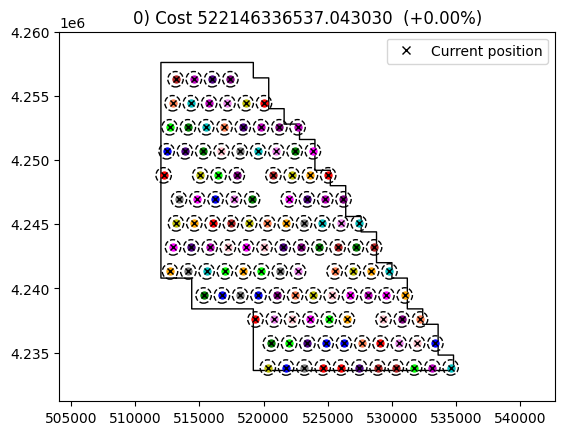

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Optimization with SGD took: 31s
Total constraint violation: 968091.5340163193


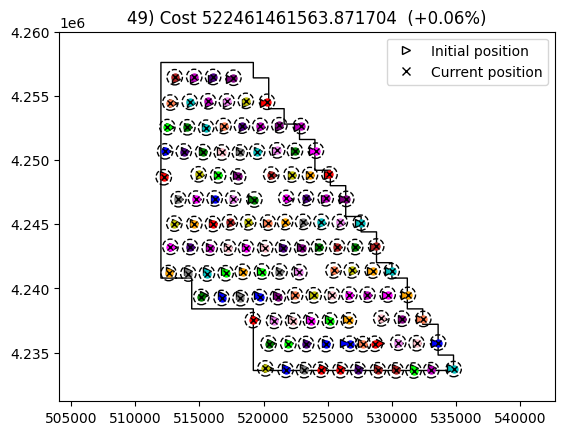

In [ ]:
# Run the optimization
tf = TopFarmProblem(
    design_vars={'x': x0, 'y': y0},
    cost_comp=cost_comps[driver_no],
    constraints=constraints[driver_no],
    driver=drivers[driver_no],
    plot_comp=XYPlotComp(),
    expected_cost=ec[driver_no]
)

tic = time.time()
cost, state, recorder = tf.optimize()
toc = time.time()

print(f'Optimization with {driver_names[driver_no]} took: {toc-tic:.0f}s')
print(f'Total constraint violation: {recorder["constraint_violation"][-1]}')
recorder.save(f'{driver_names[driver_no]}_semantic')

Loading optimization results...
Available keys in recorder: ['wtSeparationSquared', 'boundaryDistances', 'constraint_violation', 'Cost', 'cost', 'cost_comp_eval', 'x', 'xy_boundary', 'y', 'final_cost', 'plot_counter', 'counter', 'iteration_coordinate', 'timestamp', 'success', 'msg']
Using recorded AEP values from optimization
SGD AEP improvement: 0.06%


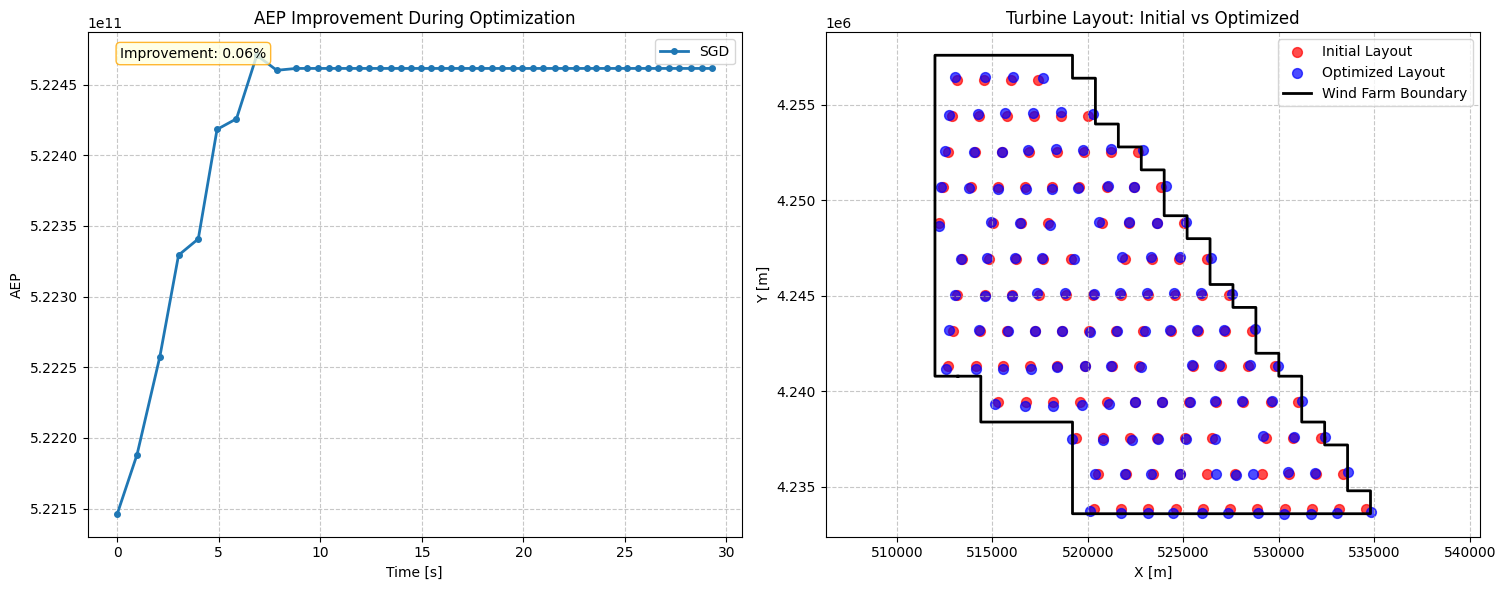


Optimization Summary:
Number of turbines: 121
Rotor diameter: 240.0 m
Minimum spacing: 1200.0 m
Initial AEP: 5.22e+11
Final AEP: 5.22e+11
Improvement: 0.06%
Optimization time: 31.4 seconds
Note: AEP values were recorded during optimization - no post-processing needed!


In [ ]:
# Analyze and visualize results - much faster now!
print("Loading optimization results...")
rec = TopFarmListRecorder().load(f'{driver_names[driver_no]}_semantic')

# Check what keys are available in the recorder
print("Available keys in recorder:", list(rec.driver_iteration_dict.keys()))

# Try to use recorded cost values, otherwise fallback to calculation
try:
    # Check if cost/objective values are recorded
    if hasattr(rec, 'driver_iteration_dict') and 'Cost' in rec.driver_iteration_dict:
        # The Cost values are negative because we're maximizing, so convert to positive
        aep = [-cost for cost in rec['Cost']]
        print("Using recorded AEP values from optimization")
    else:
        # Fallback: calculate AEP for key positions only (much faster)
        print("Cost not recorded, calculating AEP for key positions...")
        n_points = len(rec['x'])
        if n_points > 10:
            # Sample key points to reduce calculation time
            key_indices = [0, n_points//4, n_points//2, 3*n_points//4, n_points-1]
        else:
            key_indices = [0, n_points-1]
        
        aep = []
        x_sampled = []
        y_sampled = []
        timestamps_sampled = []
        
        print(f"Calculating AEP for {len(key_indices)} key positions...")
        for i in key_indices:
            # Use faster AEP calculation - these should be positive
            wd_fast = np.arange(0, 360, 5)  # 5 degree intervals
            ws_fast = np.arange(3, 25, 2)   # 2 m/s intervals
            aep_val = wake_model(rec['x'][i], rec['y'][i], wd=wd_fast, ws=ws_fast).aep().sum().values * 1e6
            aep.append(aep_val)
            x_sampled.append(rec['x'][i])
            y_sampled.append(rec['y'][i])
            timestamps_sampled.append(rec['timestamp'][i])
        
        # Use sampled data for plotting
        timestamps_plot = timestamps_sampled
        
except Exception as e:
    print(f"Error accessing recorder data: {e}")
    # Simple fallback - just calculate first and last (these should be positive)
    aep = []
    aep.append(aep_func2(rec['x'][0], rec['y'][0]))
    aep.append(aep_func2(rec['x'][-1], rec['y'][-1]))
    timestamps_plot = [rec['timestamp'][0], rec['timestamp'][-1]]
    print("Using simple first/last calculation")

# Ensure AEP values are positive (convert if they're negative due to maximization)
aep = [abs(val) for val in aep]

# Calculate improvement percentage
improvement = (aep[-1] - aep[0]) / aep[0] * 100
print(f'{driver_names[driver_no]} AEP improvement: {improvement:.2f}%')

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: AEP over time
if 'timestamps_plot' in locals():
    timestamps_relative = np.array(timestamps_plot) - timestamps_plot[0]
else:
    timestamps_relative = rec['timestamp'] - rec['timestamp'][0]

ax1.plot(timestamps_relative, aep, 'o-', label=driver_names[driver_no], linewidth=2, markersize=4)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('AEP')
ax1.set_title('AEP Improvement During Optimization')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Add improvement annotation
ax1.annotate(f'Improvement: {improvement:.2f}%', 
             xy=(0.05, 0.95), 
             xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="orange", alpha=0.8))

# Plot 2: Turbine layout comparison
ax2.scatter(x0, y0, c='red', s=50, alpha=0.7, label='Initial Layout')
ax2.scatter(rec['x'][-1], rec['y'][-1], c='blue', s=50, alpha=0.7, label='Optimized Layout')

# Plot boundary
boundary_x, boundary_y = boundary[:, 0], boundary[:, 1]
ax2.plot(boundary_x, boundary_y, 'k-', linewidth=2, label='Wind Farm Boundary')

ax2.set_xlabel('X [m]')
ax2.set_ylabel('Y [m]')
ax2.set_title('Turbine Layout: Initial vs Optimized')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axis('equal')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nOptimization Summary:")
print(f"Number of turbines: {n_wt}")
print(f"Rotor diameter: {rotor_diameter} m")
print(f"Minimum spacing: {min_spacing_m} m")
print(f"Initial AEP: {aep[0]:.2e}")
print(f"Final AEP: {aep[-1]:.2e}")
print(f"Improvement: {improvement:.2f}%")
print(f"Optimization time: {toc-tic:.1f} seconds")
print("Note: AEP values were recorded during optimization - no post-processing needed!")